# LAB 12-2 112078502 楊婷婷
Assignment  
CAPTCHA (an acronym for "Completely Automated Public Turing test to tell Computers and Humans Apart") is a type of challenge–response test used in computing to determine whether or not the user is human, which is a popular tool since it prevents spam attacks and protects websites from bots  


Requirements  

* You can use any model architectures (or any code above) you want, as long as accomplishing the goal.
* You should train your own model architecture. In other words, except the feature extractor part, do not load the model or any pre-trained weights directly from other sources.
* You can use pretrained inception_v3 as feature extractor; however, it's not recommended since inception is pretrained on ImageNet, where the image pattern is quite different to English words.
* You should use the first 100,000 images as training data, the next 20,000 as validation data, and the rest (final 20,000) as testing data.
spec_train_val.txt contains the labels of only first 120,000 images.
* Only if the whole word matches exactly does it count as correct.
* You need to predict the answer to the testing data and write them in a file.
* Your testing accuracy should be at least 90% in validation set.

Data:  
https://drive.google.com/u/1/uc?id=1mHfyM6idetIO0SO-7Aph1opWbveSeDD-&export=download


# import and check gpu

In [ ]:
import os
import tensorflow as tf

# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), 'Physical GPUs,', len(logical_gpus), 'Logical GPUs')
    except RuntimeError as e:
        print(e)


2025-11-12 09:18:20.674910: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-12 09:18:20.704484: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-12 09:18:21.408437: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1762957102.373215 3334420 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22125 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


# Load Data and pre-process

In [33]:
import glob

img_name_list = []
cap_list = []

with open('./words_captcha/spec_train_val.txt') as fin:
    for line in fin:
        image_name, caption = line.strip().split()
        img_name_list.append(f'./words_captcha/{image_name}.png')
        cap_list.append('<start> ' + ' '.join(caption) + ' <end>')

test_img_name = set(glob.glob(f'./words_captcha/*.png')) - set(img_name_list)
img_name_list += sorted(test_img_name)

# pre-process -> tokenize
tokenizer = tf.keras.preprocessing.text.Tokenizer(filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n',
                                                  oov_token='')
tokenizer.fit_on_texts(cap_list)
cap_seqs = tokenizer.texts_to_sequences(cap_list)

cap_seqs = tf.keras.preprocessing.sequence.pad_sequences(cap_seqs, padding='post')
max_length = len(cap_seqs[0])


print("before tokenize: ")
print(cap_list[0])
print("after tokenize: ")
print(len(cap_seqs[0]))
print(cap_seqs[0]) # same size, take [0] to check


before tokenize: 
<start> t h u s <end>
after tokenize: 
7
[ 2  9 18 17  6  3  0]


# Split Data : Training, Validating, Testing Data

In [34]:
# training : first 100k, val: 100k-120k, test: rest of 120k-140k
img_name_train, img_name_valid = img_name_list[:100000], img_name_list[100000:120000]
cap_seqs_train, cap_seqs_valid = cap_seqs[:100000], cap_seqs[100000:]

img_name_test = img_name_list[120000:]


# Set Hyperparameter

In [6]:
IMAGE_SIZE = (160, 300)
BATCH_SIZE = 50
BUFFER_SIZE = 5000

EMBEDDING_DIM = 256
UNITS = 512
VOCAB_SIZE = len(tokenizer.word_index) + 1
EPOCHS = 7
STEPS = len(img_name_train) // BATCH_SIZE
LEARNING_RATE = 1e-4


## Build Dataset

In [35]:
def map_train(img_path, cap_seq):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255 * 2 - 1
    return img, cap_seq

dataset_train = tf.data.Dataset.from_tensor_slices((img_name_train, cap_seqs_train))\
                               .map(map_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
                               .shuffle(BUFFER_SIZE)\
                               .batch(BATCH_SIZE, drop_remainder=True)\
                               .prefetch(tf.data.experimental.AUTOTUNE)

dataset_valid = tf.data.Dataset.from_tensor_slices((img_name_valid, cap_seqs_valid))\
                               .map(map_train, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
                               .batch(BATCH_SIZE, drop_remainder=True)\
                               .prefetch(tf.data.experimental.AUTOTUNE)


# Model Define

## Part I: feature extraction model
* In this example, you extract the features from the lower convolutional layer of InceptionV3 giving us a vector of shape (8, 8, 2048).  You squash that to a shape of (64, 2048).  (labs notes) -> not this assignment not recommend, as labs is caption, and here the capature should be exactly the same

In [40]:
from tensorflow.keras import layers
from tensorflow.keras import Input, layers, Model

class conv_leaky_relu(layers.Layer):
    def __init__(self, filters, size, stride):
        super(conv_leaky_relu, self).__init__()
        self.conv_2d = layers.Conv2D(filters, size, stride, padding='same')
        self.batch_norm = layers.BatchNormalization()
        self.leakey_relu = layers.LeakyReLU(0.1)

    def call(self, inputs):
        x = self.conv_2d(inputs)
        x = self.batch_norm(x)
        x = self.leakey_relu(x)
        return x


inputs = Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
x = conv_leaky_relu(64, 7, 2)(inputs)
x = layers.MaxPool2D()(x)
x = conv_leaky_relu(192, 3, 1)(x)
x = layers.MaxPool2D()(x)
x = conv_leaky_relu(128, 1, 1)(x)
x = conv_leaky_relu(256, 3, 1)(x)
x = conv_leaky_relu(256, 1, 1)(x)
x = conv_leaky_relu(512, 3, 1)(x)
x = layers.MaxPool2D()(x)
x = conv_leaky_relu(256, 1, 1)(x)
x = conv_leaky_relu(512, 3, 1)(x)
x = conv_leaky_relu(256, 1, 1)(x)
x = conv_leaky_relu(512, 3, 1)(x)
x = conv_leaky_relu(256, 1, 1)(x)
x = conv_leaky_relu(512, 3, 1)(x)
x = conv_leaky_relu(256, 1, 1)(x)
x = conv_leaky_relu(512, 3, 1)(x)
x = conv_leaky_relu(512, 1, 1)(x)
x = conv_leaky_relu(1024, 3, 1)(x)
x = layers.MaxPool2D()(x)
x = conv_leaky_relu(512, 1, 1)(x)
x = conv_leaky_relu(1024, 3, 1)(x)
x = conv_leaky_relu(512, 1, 1)(x)
x = conv_leaky_relu(1024, 3, 1)(x)
x = conv_leaky_relu(1024, 3, 1)(x)
x = conv_leaky_relu(1024, 3, 2)(x)
x = conv_leaky_relu(1024, 3, 1)(x)
outputs = conv_leaky_relu(1024, 3, 1)(x)



 ## Part II: 
* This vector is then passed through the CNN Encoder (which consists of a single Fully connected layer).  
* The RNN (here GRU) attends over the image to predict the next word.  
Bahdanau attention computes a context vector that tells the decoder where to focus on the encoder’s output (features) when predicting each next word. 

In [39]:
# CNN Encoder
class CNN_Encoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        self.fc = tf.keras.layers.Dense(embedding_dim)

    def call(self, x):
        # x shape after passing through fc == (batch_size, 15, embedding_dim)
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

# RNN Decoder
class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = tf.keras.layers.Dense(units)
        self.W2 = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, features, hidden):
        # features(CNN_encoder output) shape == (batch_size, 15, embedding_dim)
        # hidden shape == (batch_size, hidden_size)

        # hidden_with_time_axis shape == (batch_size, 1, hidden_size)
        hidden_with_time_axis = tf.expand_dims(hidden, 1)

        # score shape == (batch_size, 15, 1)
        score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis)))

        # attention_weights shape == (batch_size, 15, 1)
        attention_weights = tf.nn.softmax(score, axis=1)

        # context_vector == (batch_size, embedding_dim)
        context_vector = tf.reduce_sum(attention_weights * features, axis=1)

        return context_vector, attention_weights

class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units

        self.embedding = tf.keras.layers.Embedding(vocab_size, embedding_dim)
        self.gru = tf.keras.layers.GRU(self.units,
                                       return_sequences=True,
                                       return_state=True,
                                       recurrent_initializer='glorot_uniform')
        self.fc1 = tf.keras.layers.Dense(self.units)
        self.fc2 = tf.keras.layers.Dense(vocab_size)

        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        # x shape == (batch_size, 1)
        # features shape == (batch_size, 15, embedding_dim)
        # hidden shape == (batch_size, hidden_size)

        # context_vector shape == (batch_size, embedding_dim)
        # attention_weights shape == (batch_size, 15, 1)
        context_vector, attention_weights = self.attention(features, hidden)

        # x shape after passing through embedding == (batch_size, 1, embedding_dim)
        x = self.embedding(x)

        # x shape after concatenation == (batch_size, 1, embedding_dim + embedding_dim)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)

        # passing the concatenated vector to the GRU
        # output shape == (batch_size, 1, hidden_size)
        # state(hidden) shape == (batch_size, hidden_size)
        output, state = self.gru(x)

        # x shape == (batch_size, 1, hidden_size)
        x = self.fc1(output)

        # x shape == (batch_size, hidden_size)
        x = tf.reshape(x, (-1, x.shape[2]))

        # output shape == (batch_size, vocab)
        x = self.fc2(x)

        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

## Initiate Model

In [41]:
# initiate feature model
feature_extractor = Model(inputs=inputs, outputs=outputs, name='YOLO')
feature_extractor.summary()

# initiate cnn, rnn
encoder = CNN_Encoder(EMBEDDING_DIM)
decoder = RNN_Decoder(EMBEDDING_DIM, UNITS, VOCAB_SIZE)

Model: "YOLO"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_72              │ (None, 80, 150, 64)    │         9,728 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 40, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_73              │ (None, 40, 75, 192)    │       111,552 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 20, 37, 192)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_74              │ (None, 20, 37, 128)    │        25,216 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_75              │ (None, 20, 37, 256)    │       296,192 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_76              │ (None, 20, 37, 256)    │        66,816 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_77              │ (None, 20, 37, 512)    │     1,182,208 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 10, 18, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_78              │ (None, 10, 18, 256)    │       132,352 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_79              │ (None, 10, 18, 512)    │     1,182,208 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_80              │ (None, 10, 18, 256)    │       132,352 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_81              │ (None, 10, 18, 512)    │     1,182,208 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_82              │ (None, 10, 18, 256)    │       132,352 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_83              │ (None, 10, 18, 512)    │     1,182,208 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_84              │ (None, 10, 18, 256)    │       132,352 │
│ (conv_leaky_relu)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_leaky_relu_85              │ (None, 10, 18, 512)    │     1,182,208 │
│ (conv_leaky_relu)               │                        │             

 Total params: 60,208,704 (229.68 MB)

 Trainable params: 60,182,336 (229.58 MB)

 Non-trainable params: 26,368 (103.00 KB)

# Train 

In [18]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')


def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, 0))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_mean(loss_)


In [19]:
checkpoint_path = './checkpoints/YOLO/'
ckpt = tf.train.Checkpoint(feature_extractor=feature_extractor,
                           encoder=encoder,
                           decoder=decoder,
                           optimizer=optimizer)
ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)


In [ ]:
start_epoch = 0
if ckpt_manager.latest_checkpoint:
    start_epoch = int(ckpt_manager.latest_checkpoint.split('-')[-1])
    # ckpt.restore(ckpt_manager.latest_checkpoint) # if need to load and keep training
    # print(ckpt_manager.latest_checkpoint)


In [21]:
@tf.function
def train_step(img_tensor, target):
    batch_size = img_tensor.shape[0]
    dec_input = tf.expand_dims([tokenizer.word_index['<start>']] * batch_size, 1)
    hidden = decoder.reset_state(batch_size=batch_size)

    loss = 0
    with tf.GradientTape() as tape:
        features = feature_extractor(img_tensor, training=True)
        features = tf.reshape(features, (features.shape[0], -1, features.shape[3]))
        features = encoder(features)

        for i in range(1, target.shape[1]):
            predictions, hidden, _ = decoder(dec_input, features, hidden)
            loss += loss_function(target[:, i], predictions)
            # using teacher forcing
            dec_input = tf.expand_dims(target[:, i], 1)

    mean_loss = (loss / int(target.shape[1]))

    trainable_variables = feature_extractor.trainable_variables + \
        encoder.trainable_variables + decoder.trainable_variables
    gradients = tape.gradient(loss, trainable_variables)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return mean_loss


In [42]:
# as we want to see the validate of accuracy at the end of each epoch, define before training
def predict(img_tensor):
    batch_size = img_tensor.shape[0]
    dec_input = tf.expand_dims(
        [tokenizer.word_index['<start>']] * batch_size, 1)

    features = feature_extractor(img_tensor, training=False)
    features = tf.reshape(features, (features.shape[0], -1, features.shape[3]))
    features = encoder(features)

    hidden = decoder.reset_state(batch_size=batch_size)

    result = tf.expand_dims([tokenizer.word_index['<start>']] * batch_size, 1)
    for _ in range(max_length):
        predictions, hidden, _ = decoder(dec_input, features, hidden)
        predicted_id = tf.argmax(predictions, axis=1).numpy()
        dec_input = tf.expand_dims(predicted_id, 1)
        result = tf.concat([result, predicted_id.reshape((batch_size, 1))], axis=1)

    return result

def postprocess(segs):
    result_list = []
    for seq in segs:
        result = ''
        for s in seq[1:]:
            if s == tokenizer.word_index['<end>']:
                break
            result += tokenizer.index_word[s]
        result_list.append(result)
    return result_list

def evaluate(dataset_valid):
    sample_count = 0
    correct_count = 0
    for img_tensor, target in dataset_valid:
        pred_list = postprocess(predict(img_tensor).numpy())
        real_list = postprocess(target.numpy())

        for pred, real in zip(pred_list, real_list):
            sample_count += 1
            if pred == real:
                correct_count += 1

    return correct_count / sample_count

In [25]:
import time
from tqdm import tqdm

loss_plot = []
start = time.time()
for epoch in range(start_epoch, EPOCHS):
    loss = 0
    pbar = tqdm(dataset_train, total=STEPS, desc=f'Epoch {epoch + 1:2d}')
    for (step, (img_tensor, target)) in enumerate(pbar):
        loss += train_step(img_tensor, target)
        pbar.set_postfix({'loss': loss.numpy() / (step + 1)})

    loss_plot.append(loss / STEPS)
    ckpt_manager.save()

    score = evaluate(dataset_valid)
    print(f'Validation accuracy: {score:.2f}')

print('Time taken for {} epoch {} sec\n'.format(EPOCHS - start_epoch, time.time() - start))


Epoch  1: 100%|██████████| 2000/2000 [02:48<00:00, 11.87it/s, loss=1.08]
2025-11-12 09:22:56.046280: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validation accuracy: 0.44


Epoch  2: 100%|██████████| 2000/2000 [02:37<00:00, 12.70it/s, loss=0.135]
2025-11-12 09:25:56.664046: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Validation accuracy: 0.76


Epoch  3: 100%|██████████| 2000/2000 [02:35<00:00, 12.83it/s, loss=0.0504]


...

Validation accuracy: 0.91


Epoch  6: 100%|██████████| 2000/2000 [02:31<00:00, 13.20it/s, loss=0.0186]


Validation accuracy: 0.97


Epoch  7: 100%|██████████| 2000/2000 [02:31<00:00, 13.21it/s, loss=0.0122]


Validation accuracy: 0.98
Time taken for 7 epoch 1226.3186407089233 sec



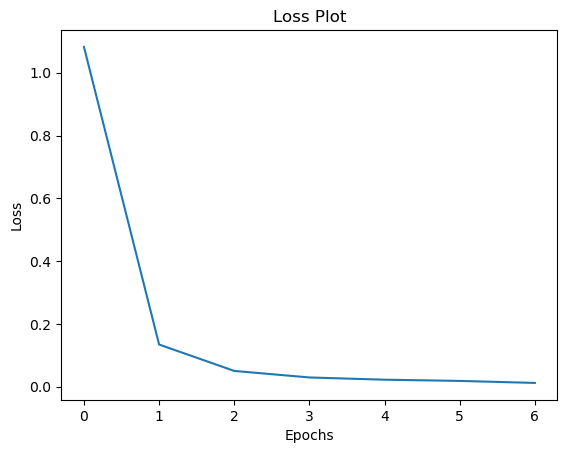

In [26]:
import matplotlib.pyplot as plt

plt.plot(loss_plot)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Plot')
plt.show()


# Run Validate Data and get the Accuracy

In [27]:
ckpt = tf.train.Checkpoint(feature_extractor=feature_extractor,
                           encoder=encoder,
                           decoder=decoder,
                           optimizer=optimizer)
ckpt.restore('./checkpoints/YOLO/ckpt-7')


In [28]:
score = evaluate(dataset_valid)
print(f'Validation accuracy: {score:.2f}')


Validation accuracy: 0.98


In [29]:
def map_test(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255 * 2 - 1
    return img, img_path

In [30]:
dataset_test = tf.data.Dataset.from_tensor_slices((img_name_test))\
                              .map(map_test, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
                              .batch(100)\
                              .prefetch(tf.data.experimental.AUTOTUNE)


# Output the Testing result

In [31]:
import re

with open('./Lab12-2_112078502.txt', 'w') as fout:
    for step, (img_tensor, img_path) in enumerate(tqdm(dataset_test)):
        pred_list = postprocess(predict(img_tensor).numpy())
        for path, pred in zip(img_path, pred_list):
            path = path.numpy().decode('utf-8')
            name = re.search('(a[0-9]+)', path).group(1)
            fout.write(f'{name} {pred}\n')


100%|██████████| 200/200 [00:12<00:00, 16.47it/s]


# Report

Model part I: 關於feature extractor:  
我嘗試用MobileNet，跟low-level representation的CNN model，但結果都不夠好，或是runtime時間太久...(參照以下trial section)沒辦法完全準確的predict出來，難以達到90%的accuracy!!  
原本想說像load比較淺層的model，可以detect到簡單的線條，比較適合用captcha的圖片，並且重新用自己的圖片去train，但最終結果僅管loss有不斷下降到1.xx (甚至再多一點epoch)的話可以再持續下降，但最後inference的效果都不好。
我覺得會失敗的很大原因是，他把圖片中雜亂干擾的線條也學習到了！而且因為這次判斷的是alphabet英文字，其實應該要有classification概念的model較佳。  

另外training的時候要調整各種dimension之間的轉換也非常不容易..

一個嘗試是用vgg19，但training時間非常久，最後參考使用YOLO1來做feature extractor，可用7個epoch就達到98%的accuracy! 很大的原因是yolo有相框好object的特性，更不會被其他雜亂線條所干擾！


Model part II: encoder, decoder和rnn都是使用助教的code  

* try with low level mobileNetV2
```python=
class FeatureExtractor(tf.keras.Model):
    def __init__(self, trainable=False, pretrained=True):
        super(FeatureExtractor, self).__init__()

        base_model = tf.keras.applications.MobileNetV2(
            include_top=False,
            weights='imagenet'if pretrained else None,
            input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3)
        )
        base_model.trainable = trainable

        # Low-level layer for stroke/edge features
        self.feature_extractor = tf.keras.Model(
            inputs=base_model.input,
            outputs=base_model.get_layer('block_3_expand_relu').output
        )

    def call(self, inputs):
        x = self.feature_extractor(inputs)
        # Dynamically infer spatial shape for reshape
        B, H, W, C = tf.unstack(tf.shape(x))
        x = tf.reshape(x, [B, H, W * C])   # flatten (height, width*C)
        return x

    def summary(self):
        inputs = tf.keras.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3))
        model = tf.keras.Model(
            name='feature_extractor_mobilenetv2_lowlevel',
            inputs=inputs,
            outputs=self.call(inputs)
        )
        return model.summary()
```

* try with lower level cnn

```python=
class FeatureExtractor(tf.keras.Model):
    def __init__(self):
        super(FeatureExtractor, self).__init__()
        # --- Block 1 ---
        self.conv1 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.conv2 = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')
        self.pool1 = tf.keras.layers.MaxPooling2D(pool_size=(2,2))

        # --- Block 2 ---
        self.conv3 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.conv4 = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')
        self.pool2 = tf.keras.layers.MaxPooling2D(pool_size=(2,2))

        # --- Block 3 ---
        self.conv5 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.conv6 = tf.keras.layers.Conv2D(256, (3,3), activation='relu', padding='same')
        self.pool3 = tf.keras.layers.MaxPooling2D(pool_size=(2,2))

        # --- Block 4 ---
        self.conv7 = tf.keras.layers.Conv2D(512, (3,3), activation='relu', padding='same')
        self.pool4 = tf.keras.layers.MaxPooling2D(pool_size=(2,2))

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.pool1(x)

        x = self.conv3(x)
        x = self.conv4(x)
        x = self.pool2(x)

        x = self.conv5(x)
        x = self.conv6(x)
        x = self.pool3(x)

        x = self.conv7(x)
        x = self.pool4(x)

        # dynamically flatten spatial dims to feed RNN
        B, H, W, C = tf.unstack(tf.shape(x))
        x = tf.reshape(x, [B, H, W*C])
        return x

    def summary(self):
        inputs = tf.keras.Input(shape=(IMAGE_WIDTH, IMAGE_HEIGHT, 3))
        model = tf.keras.Model(inputs, self.call(inputs))
        return model.summary()
```